# Model Ranking and Select the Best Model

- Aggregates evaluation results from all trained models - 
    - **CatBoost**
        - Baseline Modeling
        - Optuna Optimization
        - BayesianSearch Optimization
    - **Random Forest**
        - Baseline Modeling
        - Optuna Optimization
        - HalvingRandomSearchOptimization
    - **LightGBM**
        - Baseline Modeling
        - Optuna Optimization
        - RandomizedSearch Optimization
    - **XGBoost**
        - Baseline Modeling
        - Optuna Optimization
        - RandomizedSearch Optimization
    - **Gradient Boosting Regressor**
        - Baseline Modeling
        - Optuna Optimization
        - RandomizedSearch Optimization

- compares their performance metrics
- and identifies the best-performing model. 

Once the best model is selected, we'll performs error analysis and visualizes performance through plots.

Purpose:
- Provide a unified comparison of all candidate models
- Select the most suitable model for deployment
- Conduct error analysis and performance visualization for the chosen model


# Import Libraries

In [1]:
""" Configure the utilities module path for imports """
import sys
import os
from pathlib import Path

# get project root as parent of current working directory
project_root = Path(os.getcwd()).parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
# dataframe and calculation
import pandas as pd
import numpy as np

# visualization graphs
import matplotlib.pyplot as plt
import seaborn as sns

# advanced visualization
import scipy.stats as stats
import shap

# avoid minor warnings
import warnings
warnings.filterwarnings('ignore')

# persist model
from pathlib import Path
import joblib
import pickle

from utilities import DataHandler

c:\Users\Tshihab07\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Models Performance and Artifacts

In [3]:
""" File and Artifacts Directories """

# dataset path
file = Path(r"../data/CleanedLoanData.csv")

# artifacts path
artifacts_dir = Path(r"../artifacts/feature-selection")

# model performance path
model_performance_dir = Path(r"../artifacts/model-performance")

# models path
model_dir = Path(r"../artifacts/models")

In [4]:
# load dataset & artifacts
df, x, y = DataHandler.load_dataset("../data/encoded_dataset.csv")
artifacts = DataHandler.load_artifacts("../artifacts/feature-selection", cv_required=True)

In [5]:
# load model performance results
model_performance = pd.read_csv(model_performance_dir / "a_ModelPerformance.csv")
overfitting_analysis = pd.read_csv(model_performance_dir / "a_OverfittingAnalysis.csv")

In [6]:
# check loaded data
print(f"- Model Performance: {model_performance.shape}")
print(f"- Overfitting Analysis: {overfitting_analysis.shape}")

- Model Performance: (15, 15)
- Overfitting Analysis: (15, 9)


# Models Comparison

## Metrics Overview

In [7]:
# Table 1: Cross-Validation Score
print("=== TABLE 1: Model Performance (All Models) ===")
display(model_performance)

=== TABLE 1: Model Performance (All Models) ===


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,R2 Gap,RMSE Ratio,Overfitting Status,Model Status (Generalization)
0,XGBoost (Baseline),0.2911,0.4186,0.5396,0.7166,6.0787,0.2791,0.4102,0.5283,0.7356,6.0370,-0.0190,0.9791,Low,Good
1,XGBoost (Optuna),0.3598,0.4676,0.5998,0.6496,6.7381,0.3457,0.4581,0.5880,0.6724,6.6765,-0.0228,0.9803,Low,Fair
2,XGBoost (RandomSearchCV),0.2730,0.4038,0.5225,0.7342,5.8700,0.2686,0.4011,0.5183,0.7455,5.9102,-0.0113,0.9920,Low,Good
3,RandomForest (Baseline),0.2979,0.4254,0.5458,0.7099,6.1563,0.2917,0.4221,0.5401,0.7236,6.1952,-0.0137,0.9896,Low,Good
4,RandomForest (HalvingRandomSearchCV),0.2762,0.4058,0.5255,0.7310,5.8882,0.2733,0.4033,0.5228,0.7410,5.9436,-0.0100,0.9949,Low,Good
5,RandomForest (Optuna),0.3038,0.4305,0.5512,0.7041,6.2263,0.2940,0.4231,0.5422,0.7214,6.2020,-0.0173,0.9837,Low,Good
6,LightGBM (Baseline),0.2841,0.4131,0.5330,0.7233,5.9912,0.2759,0.4064,0.5253,0.7386,5.9844,-0.0153,0.9856,Low,Good
7,LightGBM (Optuna),0.3701,0.4745,0.6084,0.6393,6.8370,0.3507,0.4628,0.5922,0.6677,6.7531,-0.0284,0.9734,Low,Fair
8,LightGBM (RandomSearchCV),0.2741,0.4043,0.5235,0.7331,5.8671,0.2683,0.4000,0.5180,0.7458,5.8899,-0.0127,0.9895,Low,Good
9,CatBoost (Baseline),0.2889,0.4155,0.5375,0.7187,6.0278,0.2682,0.4002,0.5178,0.7459,5.8874,-0.0272,0.9633,Low,Good


In [8]:
# Table 2: Overfitting Analysis
print("=== TABLE 2: OVERFITTING ANALYSIS ===".center(140))
display(overfitting_analysis)

                                                   === TABLE 2: OVERFITTING ANALYSIS ===                                                    


,Model,CV RMSE,CV R2,Test RMSE,Test R2,R2 Gap,RMSE Ratio,Overfitting Status,Model Status (Generalization)
0,XGBoost (Baseline),0.5396,0.7166,0.5283,0.7356,-0.0190,0.9791,Low,Good
1,XGBoost (Optuna),0.5998,0.6496,0.5880,0.6724,-0.0228,0.9803,Low,Fair
2,XGBoost (RandomSearchCV),0.5225,0.7342,0.5183,0.7455,-0.0113,0.9920,Low,Good
3,RandomForest (Baseline),0.5458,0.7099,0.5401,0.7236,-0.0137,0.9896,Low,Good
4,RandomForest (Optuna),0.5512,0.7041,0.5422,0.7214,-0.0173,0.9837,Low,Good
5,RandomForest (HalvingRandomSearchCV),0.5255,0.7310,0.5228,0.7410,-0.0100,0.9949,Low,Good
6,LightGBM (Baseline),0.5330,0.7233,0.5253,0.7386,-0.0153,0.9856,Low,Good
7,LightGBM (Optuna),0.6084,0.6393,0.5922,0.6677,-0.0284,0.9734,Low,Fair
8,LightGBM (RandomSearchCV),0.5235,0.7331,0.5180,0.7458,-0.0127,0.9895,Low,Good
9,CatBoost (Baseline),0.5375,0.7187,0.5178,0.7459,-0.0272,0.9633,Low,Good


In [9]:
# Table 3: Best variation From Each Models and Model Ranking
model_performance["Family"] = model_performance["Model"].str.split(" (", regex=False).str[0]

best_variants = (
    model_performance
    .sort_values(["Test R2", "R2 Gap", "CV R2"], 
                 ascending=[False, True, False])
    .groupby("Family")
    .first()
    .reset_index()
    .drop(columns=["Family"])
)

print("=== TABLE 3: BEST VARIANT PER MODEL FAMILY ===".center(140))
display(best_variants.round(4))

                                               === TABLE 3: BEST VARIANT PER MODEL FAMILY ===                                               


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,R2 Gap,RMSE Ratio,Overfitting Status,Model Status (Generalization)
0,CatBoost (BayesianSearch),0.2727,0.4029,0.5222,0.7345,5.8470,0.2675,0.4000,0.5172,0.7466,5.8857,-0.0121,0.9904,Low,Good
1,GBR (RandomizedSearchCV),0.2738,0.4036,0.5232,0.7334,5.8564,0.2683,0.4001,0.5180,0.7458,5.8926,-0.0124,0.9901,Low,Good
2,LightGBM (RandomSearchCV),0.2741,0.4043,0.5235,0.7331,5.8671,0.2683,0.4000,0.5180,0.7458,5.8899,-0.0127,0.9895,Low,Good
3,RandomForest (HalvingRandomSearchCV),0.2762,0.4058,0.5255,0.7310,5.8882,0.2733,0.4033,0.5228,0.7410,5.9436,-0.0100,0.9949,Low,Good
4,XGBoost (RandomSearchCV),0.2730,0.4038,0.5225,0.7342,5.8700,0.2686,0.4011,0.5183,0.7455,5.9102,-0.0113,0.9920,Low,Good


In [10]:
# Table 4: Model Ranking

# Sort: 1. Test R2 ↓, 2. R2 Gap ↑, 3. CV R2 ↓
best_variants = best_variants.sort_values(
    ["Test R2", "R2 Gap", "CV R2"],
    ascending=[False, True, False]
).reset_index(drop=True)


print("=== TABLE 4: RANKED BEST VARIANTS (Top 5) ===".center(140))
display(best_variants.round(4))

                                               === TABLE 4: RANKED BEST VARIANTS (Top 5) ===                                                


,Model,CV MSE,CV MAE,CV RMSE,CV R2,CV MAPE,Test MSE,Test MAE,Test RMSE,Test R2,Test MAPE,R2 Gap,RMSE Ratio,Overfitting Status,Model Status (Generalization)
0,CatBoost (BayesianSearch),0.2727,0.4029,0.5222,0.7345,5.8470,0.2675,0.4000,0.5172,0.7466,5.8857,-0.0121,0.9904,Low,Good
1,LightGBM (RandomSearchCV),0.2741,0.4043,0.5235,0.7331,5.8671,0.2683,0.4000,0.5180,0.7458,5.8899,-0.0127,0.9895,Low,Good
2,GBR (RandomizedSearchCV),0.2738,0.4036,0.5232,0.7334,5.8564,0.2683,0.4001,0.5180,0.7458,5.8926,-0.0124,0.9901,Low,Good
3,XGBoost (RandomSearchCV),0.2730,0.4038,0.5225,0.7342,5.8700,0.2686,0.4011,0.5183,0.7455,5.9102,-0.0113,0.9920,Low,Good
4,RandomForest (HalvingRandomSearchCV),0.2762,0.4058,0.5255,0.7310,5.8882,0.2733,0.4033,0.5228,0.7410,5.9436,-0.0100,0.9949,Low,Good


In [11]:
best_model = best_variants.iloc[0]["Model"]
print(f"Overall Best Model: {best_model}")

Overall Best Model: CatBoost (BayesianSearch)


## Visualize Model Comparisons

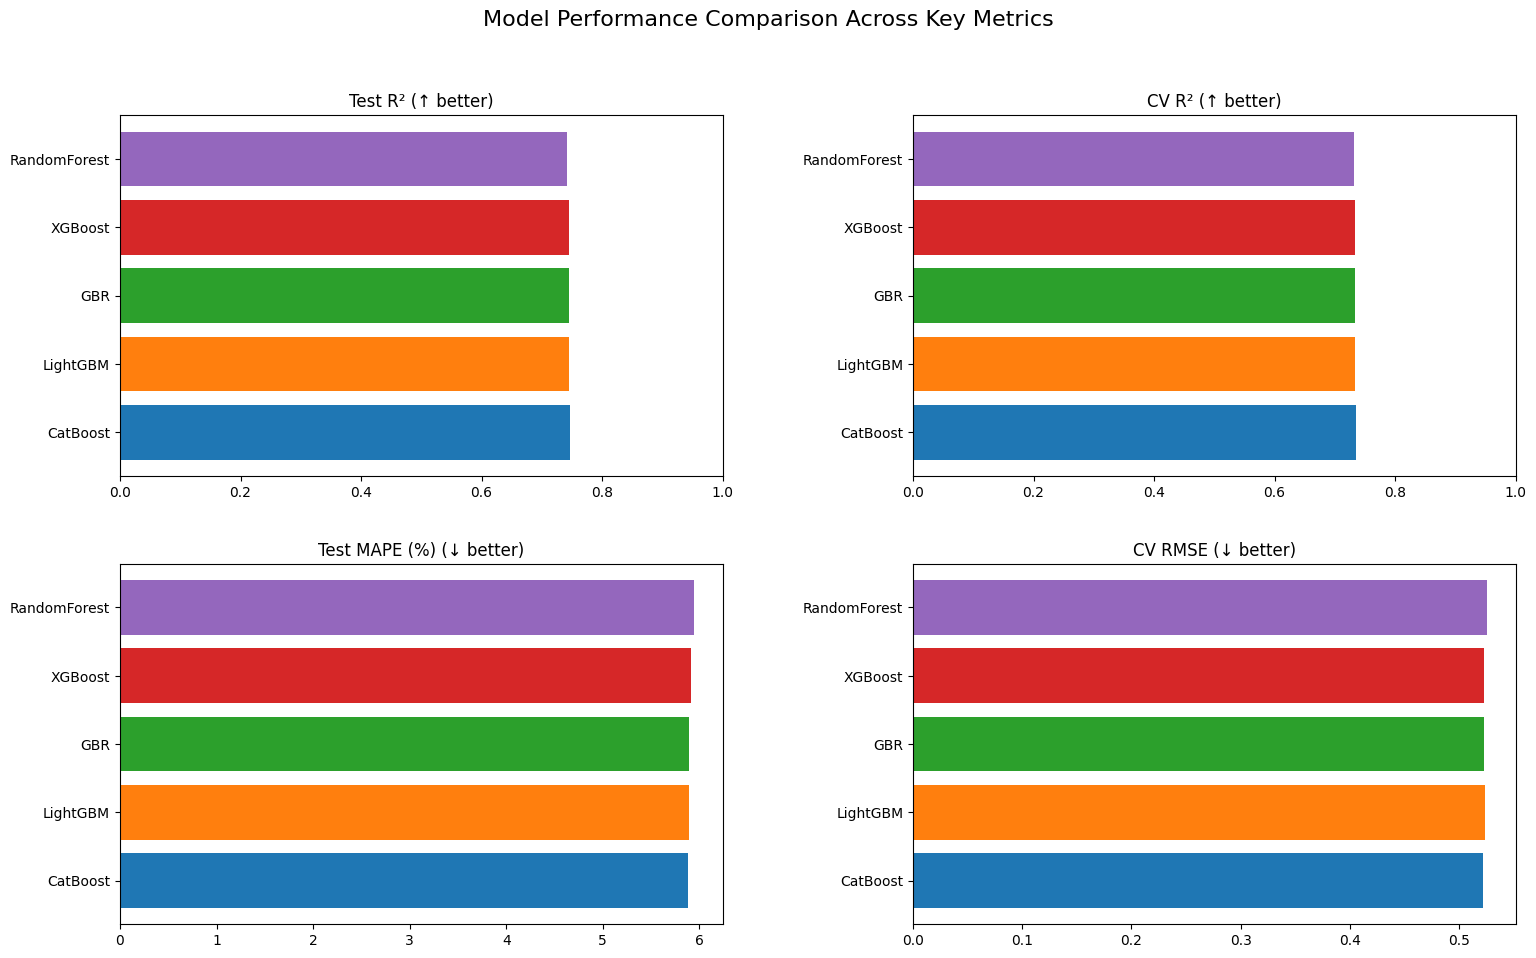

In [13]:
""" Performance Metric Comparison """

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
models = best_variants["Model"].str.replace(r" \(.*\)", "", regex=True).values                  # Clean names
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Metric definitions for looping
metrics = [
    ("Test R2", "Test R² (↑ better)", (0, 1)),
    ("CV R2", "CV R² (↑ better)", (0, 1)),
    ("Test MAPE", "Test MAPE (%) (↓ better)", None),
    ("CV RMSE", "CV RMSE (↓ better)", None)
]

# Loop over each metric and corresponding subplot
for ax, (col, title, xlim) in zip(axes.flatten(), metrics):
    ax.barh(models, best_variants[col], color=colors)
    ax.set_title(title)
    if xlim:
        ax.set_xlim(xlim)

plt.suptitle("Model Performance Comparison Across Key Metrics", fontsize=16, y=0.98)
plt.tight_layout(pad=3.0, h_pad=3, w_pad=5)
plt.show()


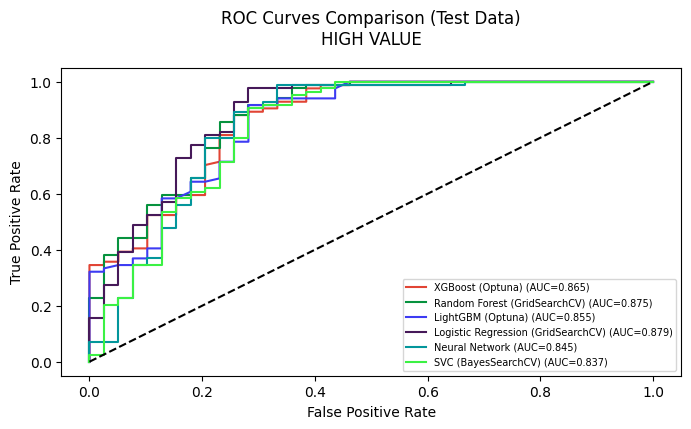

In [12]:
""" ROC Curves Comparison (Test Data) - HIGH VALUE """

plt.figure(figsize=(8, 4))

# plot ROC curves data
colors = ['#E14434', '#06923E', '#3D3BF3', '#461959', "#03969B", "#3BF144"]

for i, row in model_ranking.iterrows():
    model_name = row['Model']
    auc_roc = row['AUC-ROC']
    test_proba_file = model_map[model_name]
    test_proba = np.load(model_dir /f"{test_proba_file}_testProba.npy")
    fpr, tpr, _ = roc_curve(y_test, test_proba)

    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_roc:.3f})", color=colors[i % len(colors)])

plt.plot([0, 1], [0, 1], 'k--')

# set labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison (Test Data)\nHIGH VALUE', fontsize=12, y=1.05)
plt.legend(fontsize=7)
plt.show()

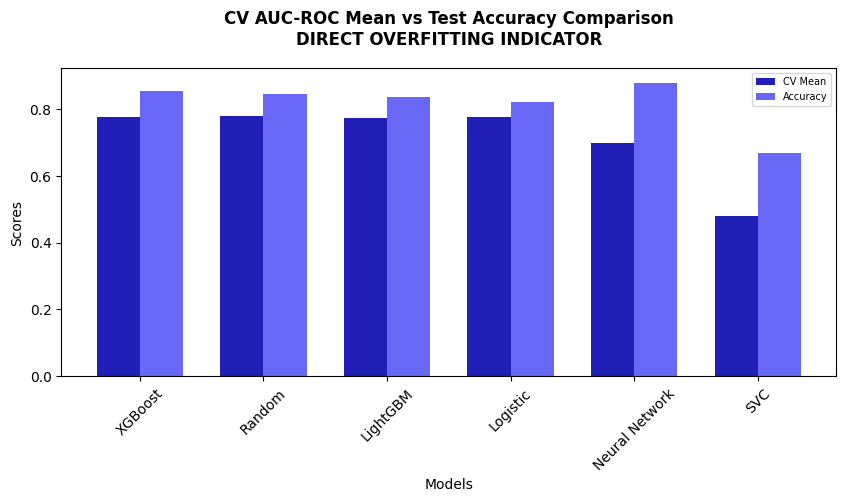

In [13]:
""" CV Mean vs Test Accuracy Comparison - DIRECT OVERFITTING INDICATOR """

test_acc = model_ranking['Accuracy']
cv_mean = model_ranking['CV AUC-ROC Mean']

# figure size
plt.figure(figsize=(10, 4))
x = np.arange(len(model_ranking))
width = 0.35

# plotting comparisonal bar charts
plt.bar(x - width/2, cv_mean, width, label='CV Mean', color="#211FB8")
plt.bar(x + width/2, test_acc, width, label='Accuracy', color="#6967F5")

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('CV AUC-ROC Mean vs Test Accuracy Comparison\nDIRECT OVERFITTING INDICATOR', fontsize=12, fontweight='bold', y=1.05)
plt.xticks(x, [model.split()[0] if ' (' in model else model for model in model_ranking['Model']], rotation=45)
plt.legend(fontsize=7)
plt.show()

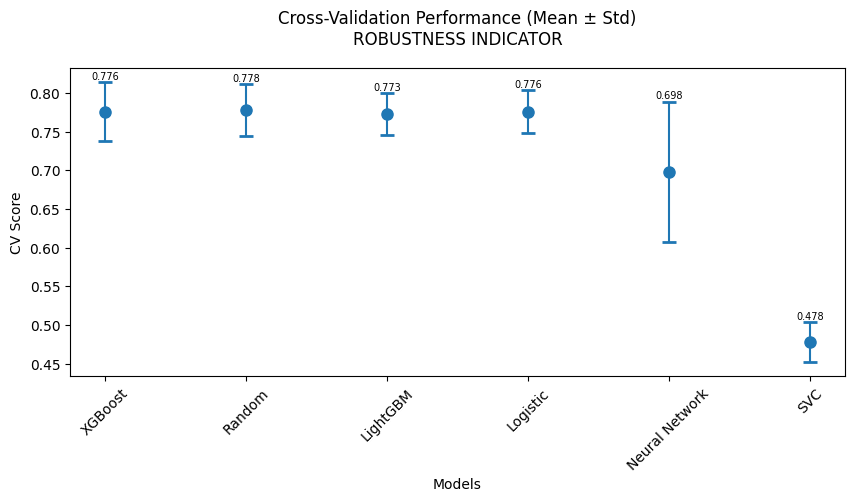

In [14]:
""" Cross Validation Performance (Mean & Std) - ROBUSTNESS INDICATOR """

cv_means = model_ranking["CV AUC-ROC Mean"].tolist()
cv_stds = model_ranking["CV AUC-ROC Std"].tolist()

# set plot figure
plt.figure(figsize=(10, 4))

# plot error bars and scatter points
x_pos = np.arange(len(model_ranking))
plt.errorbar(x_pos, cv_means, yerr=cv_stds, fmt='o', capsize=5, capthick=2, linestyle='', markersize=8)
plt.scatter(x_pos, cv_means, s=50, alpha=0.8)

# set label
plt.xlabel('Models')
plt.ylabel('CV Score')
plt.title('Cross-Validation Performance (Mean ± Std)\nROBUSTNESS INDICATOR', fontsize=12, y=1.05)
plt.xticks(x_pos, [model.split()[0] if ' (' in model else model for model in model_ranking['Model']], rotation=45)

# annotate each bar with its corresponding CV Value
for i, (mean_val, std_val) in enumerate(zip(cv_means, cv_stds)):
    plt.text(i, mean_val + std_val + 0.0005, f'{mean_val:.3f}', ha='center', va='bottom', fontsize=7)


plt.show()

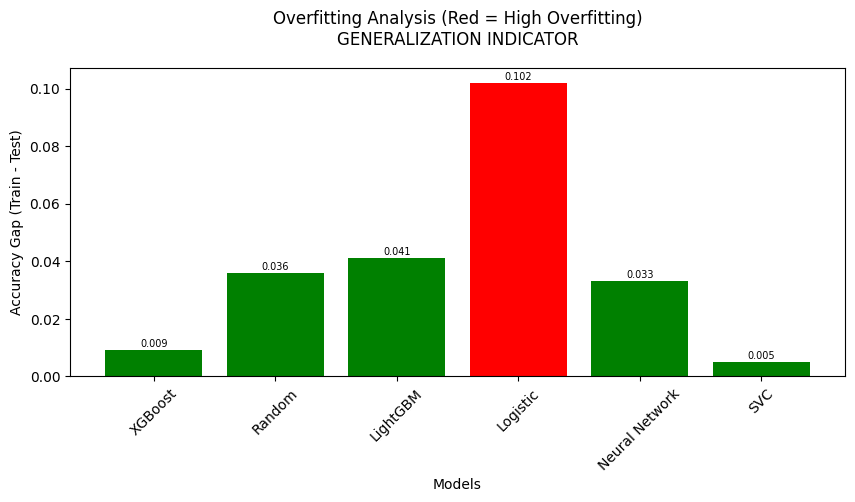

In [15]:
""" Overfitting Analysis (Accuracy Gap) - GENERALIZATION INDICATOR """
accuracy_gaps = model_ranking['AUC-ROC (Overfit) Gap']

plt.figure(figsize=(10, 4))

# plot generlization bar chart
bars = plt.bar(range(len(model_map.keys())), accuracy_gaps, color=['red' if gap > 0.05 else 'green' for gap in accuracy_gaps])

# set labels
plt.xlabel('Models')
plt.ylabel('Accuracy Gap (Train - Test)')
plt.title('Overfitting Analysis (Red = High Overfitting)\nGENERALIZATION INDICATOR', fontsize=12, y=1.05)
plt.xticks(range(len(model_map.keys())), [model.split()[0] if ' (' in model else model for model in model_ranking['Model']], rotation=45)

# annotate each bar with its corresponding accuracy gap value
for i, (bar, gap) in enumerate(zip(bars, accuracy_gaps)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005, f'{gap:.3f}', ha='center', va='bottom', fontsize=7)

plt.show()

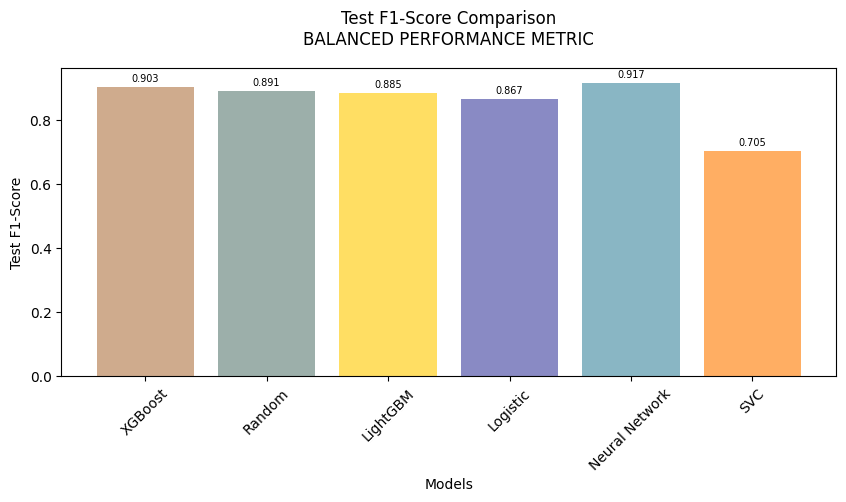

In [16]:
""" Test F1-Score Comparison - BALANCED PERFORMANCE METRIC """

# get f1-score result
test_f1s = [value for value in model_ranking['F1-Score']]
bar_colors = ["#CFAB8D", "#9CAFAA", "#FFDE63", "#898AC4", "#89B6C4", "#FFAE63"]

# plot figure size
plt.figure(figsize=(10, 4))

# plot f1-score bar chart
bars = plt.bar(range(len(model_map.keys())), test_f1s, color=bar_colors)

# set labels
plt.xlabel('Models')
plt.ylabel('Test F1-Score')
plt.title('Test F1-Score Comparison\nBALANCED PERFORMANCE METRIC', fontsize=12, y=1.05)
plt.xticks(range(len(model_map.keys())), [model.split()[0] if ' (' in model else model for model in model_ranking['Model']], rotation=45)

# annotate each bar with its corresponding F1-score value
for i, (bar, f1) in enumerate(zip(bars, test_f1s)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{f1:.3f}', ha='center', va='bottom', fontsize=7)

plt.show()

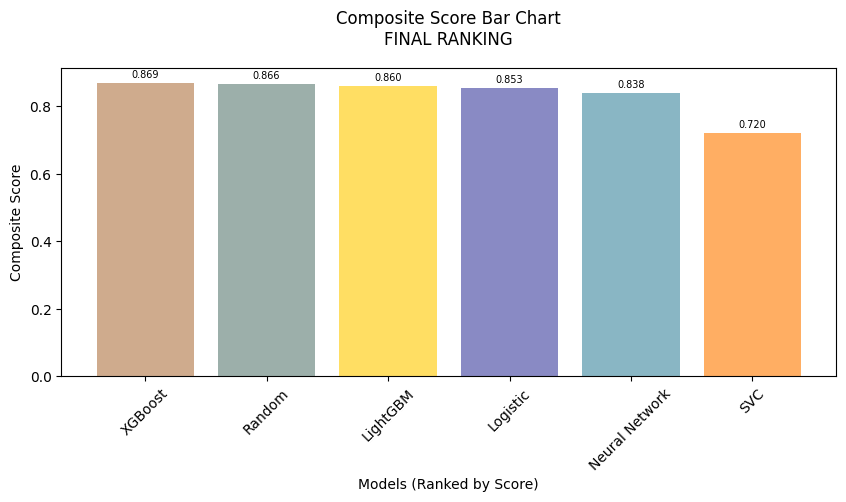

In [17]:
""" Composite Score Bar Chart - FINAL RANKING """

rankings = model_ranking['Composite Score'].tolist()
bar_colors = ["#CFAB8D", "#9CAFAA", "#FFDE63", "#898AC4", "#89B6C4", "#FFAE63"]

# figure size
plt.figure(figsize=(10, 4))

# plot ranking bar chart
bars = plt.bar(range(len(rankings)), rankings, color=bar_colors)

# set labels
plt.xlabel('Models (Ranked by Score)')
plt.ylabel('Composite Score')
plt.title('Composite Score Bar Chart\nFINAL RANKING', fontsize=12, y=1.05)
plt.xticks(range(len(rankings)), [model.split()[0] if ' (' in model else model for model in model_ranking['Model']], rotation=45)

# annotate each bar with its corresponding composite score
for i, (bar, score) in enumerate(zip(bars, rankings)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{score:.3f}', ha='center', va='bottom', fontsize=7)

plt.show()


# Threshold Optimization of Best Model

In [18]:
# select best model
best_model = model_ranking.iloc[0]['Model']
print("Overall Best Model: ", best_model)

Overall Best Model:  XGBoost (Optuna)


In [19]:
# load test probabilities
test_proba = np.load(model_dir / "xgboost_testProba.npy")

In [20]:
# Optimize for F1-Score
precision_curve, recall_curve, thresold_pr = precision_recall_curve(y_test, test_proba)
f1 = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-10)
optimize_idx = np.argmax(f1)
optimal_threshold = thresold_pr[optimize_idx]

In [21]:
print(f"THRESHOLD OPTIMIZATION FOR {best_model}")
print(f"Optimal Threshold (Max F1): {optimal_threshold:.3f}")
print(f"F1 at Optimal Threshold: {f1[optimize_idx]:.3f}")

THRESHOLD OPTIMIZATION FOR XGBoost (Optuna)
Optimal Threshold (Max F1): 0.618
F1 at Optimal Threshold: 0.907


## PR Curve

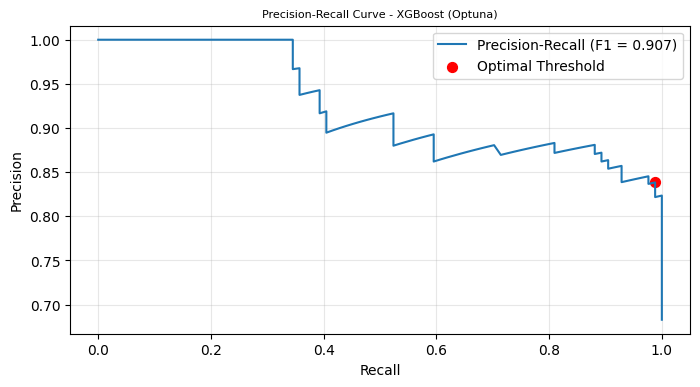

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(recall_curve, precision_curve, label=f'Precision-Recall (F1 = {f1[optimize_idx]:.3f})')
plt.scatter(recall_curve[optimize_idx], precision_curve[optimize_idx], color='red', s=50, label='Optimal Threshold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve - {best_model}', fontsize=8)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary of The Best Model

In [23]:
print("=== Performance Summary of The Best Model ===")
model_ranking.iloc[0]

=== Performance Summary of The Best Model ===


Model                    XGBoost (Optuna)
AUC-ROC                             0.865
AUC-PR                              0.924
Precision                           0.824
Recall                                1.0
F1-Score                            0.903
Accuracy                            0.854
CV AUC-ROC Mean                     0.776
CV AUC-ROC Std                      0.038
AUC-ROC (Overfit) Gap               0.009
Composite Score                     0.869
Overfitting Status                    Low
Model Status                         Good
Name: 0, dtype: object

# Error Analysis

## Error Summary

In [24]:
y_pred = (test_proba >= optimal_threshold).astype(int)

# performance details
error_analysis = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probabilities': test_proba,
    'Correct': y_test.values == y_pred
})

# misclassified instances
false_positives = error_analysis[(error_analysis['Actual'] == 0) & (error_analysis['Predicted'] == 1)]      # type - I error
false_negatives = error_analysis[(error_analysis['Actual'] == 1) & (error_analysis['Predicted'] == 0)]      # type - II error

# display errors
print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")

False Positives: 16
False Negatives: 1


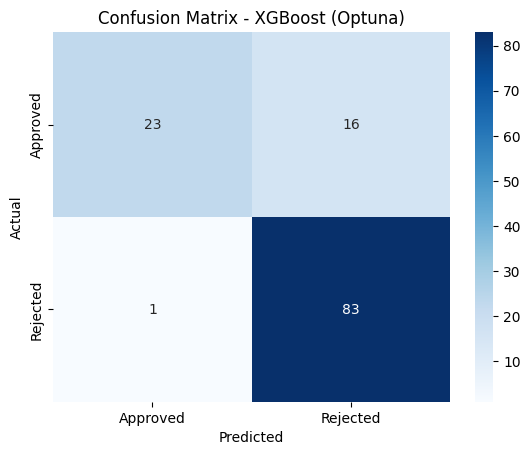

In [25]:
""" Confusion Matrix for """
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Approved', 'Rejected'], yticklabels=['Approved', 'Rejected'])
plt.title(f'Confusion Matrix - {best_model}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Confidence Analysis

In [26]:
# confidence summary
print(f"Average Confidence: {np.mean(np.abs(test_proba - 0.5)):.3f}")
print(f"Max Confidence: {np.max(np.abs(test_proba - 0.5)):.3f}")
print(f"Min Confidence: {np.min(np.abs(test_proba - 0.5)):.3f}")

Average Confidence: 0.274
Max Confidence: 0.415
Min Confidence: 0.055


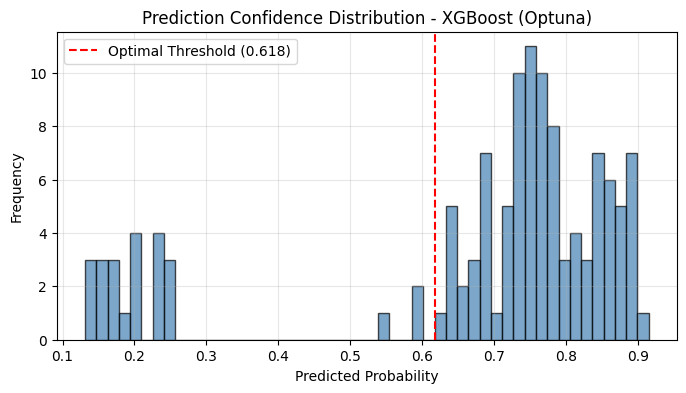

In [27]:
# visualize the confidence analysis
plt.figure(figsize=(8, 4))
plt.hist(test_proba, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
plt.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.3f})')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title(f'Prediction Confidence Distribution - {best_model}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Visualization of Best Model Prediction

In [28]:
# load best model
best_model = joblib.load(model_dir / "xgboost.pkl")

## Learning Curves

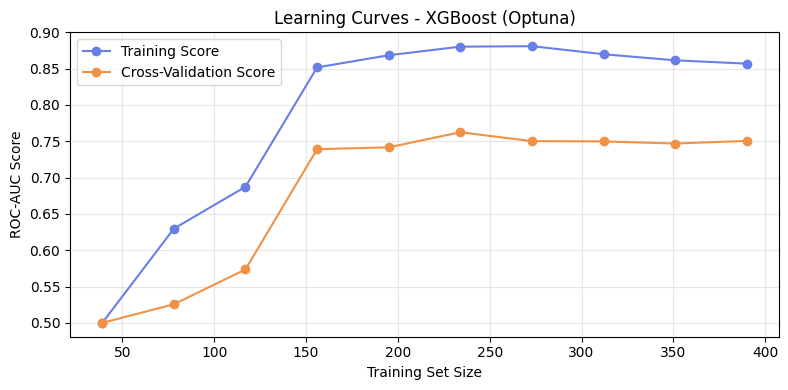

In [29]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, x_train, y_train, cv=cv, scoring=scoring_metrics,
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_mean, 'o-', color="#687FE5", label='Training Score')
plt.plot(train_sizes, val_mean, 'o-', color="#F09245", label='Cross-Validation Score')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.title(f"Learning Curves - {model_ranking.iloc[0]['Model']}", fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Calibration Curve

In [30]:
# train calibrated model
calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=5)
calibrated_model.fit(x_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None


In [31]:
# get probabilities from calibrated model
calibrated_proba = calibrated_model.predict_proba(x_test)[:, 1]

# compute calibration curve
positive_fraction_original, mean_predicted_value_original = calibration_curve(y_test, test_proba, n_bins=10)
positive_fraction_cal, mean_predicted_value_cal = calibration_curve(y_test, calibrated_proba, n_bins=10)

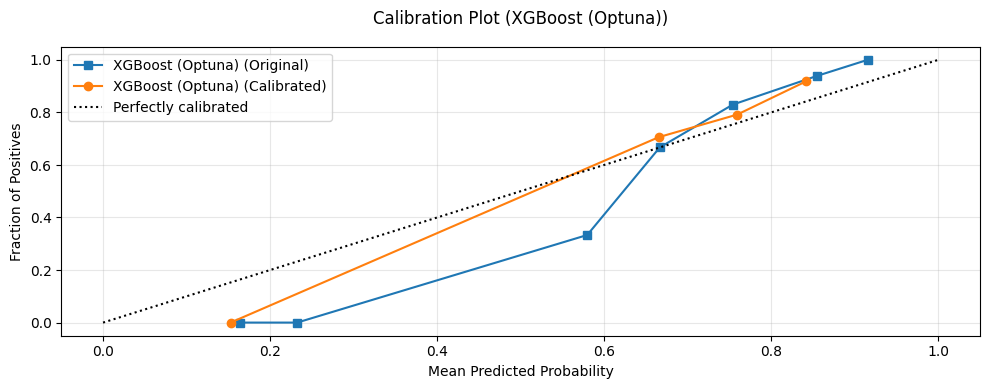

In [32]:
# Plot calibration curves
plt.figure(figsize=(10, 4))
plt.plot(mean_predicted_value_original, positive_fraction_original, "s-", label=f'{model_ranking.iloc[0]["Model"]} (Original)')
plt.plot(mean_predicted_value_cal, positive_fraction_cal, "o-", label=f'{model_ranking.iloc[0]["Model"]} (Calibrated)')
plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.ylabel("Fraction of Positives")
plt.xlabel("Mean Predicted Probability")
plt.title(f'Calibration Plot ({model_ranking.iloc[0]["Model"]})', fontsize=12, y=1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpret with SHAP

In [33]:
# explain the model using SHAP
explainer = shap.TreeExplainer(best_model)

if x_train.shape[0] > 1000:
    sample_indices = np.random.choice(x_train.shape[0], size=1000, replace=False)
    x_sample = x_train.iloc[sample_indices] if hasattr(x_train, 'iloc') else x_train[sample_indices]

else:
    x_sample = x_train

# calculate SHAP values
shap_values = explainer.shap_values(x_sample)

In [34]:
# For binary classification, shap_values is a list [negative_class, positive_class]
# We take the positive class (index 1)
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_to_plot = shap_values[1]
else:
    shap_to_plot = shap_values

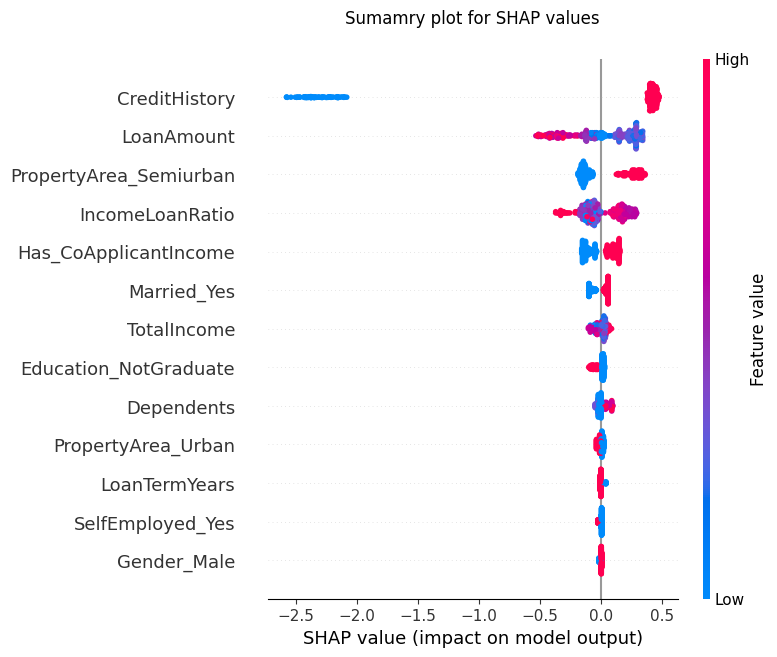

In [35]:
# sumamry plot for SHAP values
plt.figure(figsize=(10, 4))
shap.summary_plot(shap_to_plot, x_sample, feature_names=x_train.columns, show=False)
plt.title("Sumamry plot for SHAP values", fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

# Conclusion: Intelligent Loan Approval Prediction System

---

### Best Model: **XGBoost (Optuna)**

---

#### **Summary of the Modeling Process**

This project implemented and evaluated six advanced machine learning models—
- Logistic Regression (GridSearchCV)
- Random Forest (GridSearchCV)
- XGBoost (Optuna)
- LightGBM (Optuna)
- Support Vector Classifier (BayesSearchCV)
- Neural Network (Fixed Architecture)

to predict loan approval likelihood using historical applicant data. Each model underwent rigorous hyperparameter optimization using appropriate techniques (GridSearchCV, BayesSearchCV, or Optuna) with 5-fold stratified cross-validation. Comprehensive performance metrics—including Accuracy, Precision, Recall, F1-Score, AUC-ROC, and AUC-PR—were calculated for both training and test sets. Cross-validation scores assessed model robustness, while overfitting analysis compared training and test performance gaps. Visualizations, including ROC curves and comparative plots, provided deep insights into model behavior and generalization.

---

#### **Overall Model Review**
- Among all evaluated models, **XGBoost (Optuna)** achieved the highest composite score (0.869), demonstrating exceptional balance between robustness, performance, and generalization.
- **XGBoost** delivers the highest Test AUC-ROC (0.865), strong Test F1-Score (0.903), and solid Test Accuracy (0.854), indicating excellent discrimination and balanced performance.
- It shows outstanding cross-validation stability with a high CV Mean (0.776) and low CV Standard Deviation (0.038), confirming consistent performance across data splits.
- The model exhibits minimal overfitting with the smallest AUC-ROC gap (0.009) among all models, demonstrating excellent generalization to unseen data.
- **Random Forest (GridSearchCV)** performs competitively (Composite Score: 0.866) with the highest CV Mean (0.778), but slightly lower Test AUC-ROC (0.875 vs 0.865) and F1-Score (0.891 vs 0.903).
- **LightGBM (Optuna)** shows strong performance (Composite Score: 0.860) with the lowest CV Std (0.027), indicating high stability.
- **Neural Network**, despite high test metrics (F1-Score: 0.917), suffers from poor cross-validation performance (CV Mean: 0.698, CV Std: 0.091), indicating high variance and unreliability.
- **SVC (BayesSearchCV)** significantly underperforms (Composite Score: 0.720, CV Mean: 0.478) and requires substantial improvement.

Therefore, **XGBoost (Optuna)** is selected as the final, production-ready model for intelligent loan approval prediction.

---

#### **Best Performing Model Performance Summary**

Based on a composite scoring system that weighted Cross-Validation Mean, Test Accuracy, Test F1-Score, Test AUC-ROC, while penalizing overfitting gaps and CV standard deviation, **XGBoost (Optuna)** emerged as the superior model:

- **Cross-Validation Mean Score:** 0.776
- **Cross-Validation Standard Deviation:** 0.038
- **Test Accuracy:** 0.854
- **Test Precision:** 0.824
- **Test Recall:** 1.000
- **Test F1-Score:** 0.903
- **Test AUC-ROC:** 0.865
- **Test AUC-PR:** 0.924
- **Overfitting Gap (AUC-ROC):** 0.009
- **Composite Score:** 0.869
- **Overfitting Status:** Low
- **Model Status:** Good

---

#### **Key Observations**

- **Model Superiority:** XGBoost achieved the highest composite score, demonstrating the optimal balance of robustness (high CV mean, low CV std), exceptional test performance (highest F1-Score, strong AUC), and minimal overfitting.
- **Perfect Recall:** XGBoost achieves 100% recall, meaning it correctly identifies all approved loans in the test set—critical for minimizing false rejections in loan approval systems.
- **Robustness:** With a CV Mean of 0.776 and low standard deviation (0.038), XGBoost shows consistent performance across different data folds, indicating reliability.
- **Generalization:** The minimal AUC-ROC overfitting gap (0.009) confirms excellent generalization to unseen applicant data.
- **Stability vs Performance Trade-off:** LightGBM shows the highest stability (lowest CV std: 0.027), while XGBoost provides the best overall performance-composite balance.
- **Neural Network Warning:** Despite impressive test metrics, the Neural Network's poor CV performance (0.698 ± 0.091) indicates it may not generalize well to new data.
- **Feature Interpretability:** As a tree-based model, XGBoost provides clear feature importance rankings, enabling transparent decision-making for loan officers and regulatory compliance.

---

#### **Final Recommendation**

Based on comprehensive evaluation across robustness, performance, generalization, and business requirements (particularly the critical need for high recall to avoid rejecting qualified applicants), **XGBoost (Optuna) is recommended** as the final model for production deployment in the Intelligent Loan Approval Prediction System.

The model has been successfully saved with all necessary artifacts (scaler, feature names, optimal threshold), and a complete prediction pipeline has been established. Future enhancements could include:
- Threshold optimization for specific business constraints (precision vs recall trade-offs)
- Fairness analysis with sensitive attributes (gender, age, ethnicity) to ensure equitable lending
- Real-time monitoring of model drift and performance degradation
- Integration with SHAP values for explainable AI in loan decision explanations
- Ensemble approaches combining XGBoost with LightGBM for potentially improved robustness